In [ ]:
!pip install pandas
!pip install js
!pip install sdv


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 9.8 MB/s eta 0:00:00
  Created wheel for js: filename=js-1.0-py3-none-any.whl size=2883 sha256=0ac0a56697372f4cbe9c459128af09a42243c26142847f53d2b1f92e4908eea3
  Stored in directory: /root/.cache/pip/wheels/36/ef/97/22589ad7139b0b24351f1e84763d4b2fd2d29e1f3db425f697
Successfully built js
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.9/209.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.0/207.0 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7

In [ ]:
import io
import js  # Pyodide bridge to the browser's JS environment
import pandas as pd
import numpy as np
import sdv
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
async def fetch_csv_text(u: str) -> str:
    """Fetch CSV text from a URL using a CORS-enabled fetch and return it as a string.

    This function uses Pyodide's JavaScript bridge to perform an HTTP GET against the given
    URL with CORS mode enabled, and returns the response body as a Python string.

    Steps:
    - perform a fetch request with CORS
    - if the response is not OK, raise a runtime error with status details
    - obtain the response text, which may be a Promise-like object
    - await the text if it is awaitable
    - coerce non-string results to a string
    - return the final string

    Args:
        u: The URL to fetch.

    Returns:
        The response body as a string.

    Raises:
        RuntimeError: If the HTTP response status indicates failure.
    """
    resp = await js.fetch(u, {"mode": "cors"})  # initiate fetch with CORS mode

    if not resp.ok:  # check if the HTTP response status is not in 200-299
        raise RuntimeError(f"Fetch failed: {resp.status} {resp.statusText}")  # raise with status details

    t = resp.text()  # get a Promise-like object for the response text

    if hasattr(t, "__await__"):  # if the text is awaitable (e.g., a Promise)
        t = await t  # wait for the promise to resolve to the actual text

    if not isinstance(t, str):  # ensure the result is a string
        t = str(t)  # coerce non-string types to string

    return t  # return the final text as a Python string

In [ ]:
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMSkillsNetwork-AI0271EN-SkillsNetwork/labs/v1/m3/data/used_car_price_analysis.csv"

# Pandas can read directly from a URL
df = pd.read_csv(URL)
# csv_text = await fetch_csv_text(URL) #Calls the asynchronous function fetch_csv_text with the URL, and waits for it to complete. The result (the CSV file contents as a string) is stored in csv_text.
# df = pd.read_csv(io.StringIO(csv_text)) # Wraps the CSV string in a file-like object using io.StringIO so it can be read by pandas. Reads the CSV data into a pandas DataFrame named df.
print("Data shape:", df.shape)
print(df.head())
n_raw_samples = df.shape[0]

Data shape: (17966, 9)
     model  year transmission  mileage fuelType    tax   mpg  engineSize  \
0   Fiesta  2017    Automatic    15944   Petrol  150.0  57.7         1.0   
1    Focus  2018       Manual     9083   Petrol  150.0  57.7         1.0   
2    Focus  2017       Manual    12456   Petrol  150.0  57.7         1.0   
3   Fiesta  2019       Manual    10460   Petrol  145.0  40.3         1.5   
4   Fiesta  2019    Automatic     1482   Petrol  145.0  48.7         1.0   

   price  
0  12000  
1  14000  
2  13000  
3  17500  
4  16500  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   transmission  17966 non-null  object 
 3   mileage       17966 non-null  int64  
 4   fuelType      17966 non-null  object 
 5   tax           17963 non-null  float64
 6   mpg           17966 non-null  float64
 7   engineSize    17966 non-null  float64
 8   price         17966 non-null  int64  
dtypes: float64(3), int64(3), object(3)
memory usage: 1.2+ MB


In [ ]:
df[['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']].isna().sum()


,0
year,0
mileage,0
tax,3
mpg,0
engineSize,0
price,0


# Data Preparation

## Data Cleaning

In [ ]:
missing_cols = [col for col in df.columns if df[col].isna().any()]

if missing_cols:
    print("Columns with missing values:")
    for col in missing_cols:
        missing_count = int(df[col].isna().sum())
        print(f"- {col}: {missing_count} missing")
else:
    print("No columns with missing values found.")

Columns with missing values:
- tax: 3 missing


### Basic type coercion
Handles bad values gracefully with errors='coerce' — any value that can't be converted to a number (like a stray string, typo, or blank) gets turned into NaN instead of raising an error.

In [ ]:
for col in ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'price']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

### Handle missing values (simple policy)
Substitute "NA" byt the median

In [ ]:
df['year'] = df['year'].fillna(df['year'].median())
df['mileage'] = df['mileage'].fillna(df['mileage'].median())
df['tax'] = df['tax'].fillna(df['tax'].median())
df['mpg'] = df['mpg'].fillna(df['mpg'].median())
df['engineSize'] = df['engineSize'].fillna(df['engineSize'].median())
df['price'] = df['price'].fillna(df['price'].median())

for cat in ['model', 'transmission', 'fuelType']:
    if cat in df.columns:
        df[cat] = df[cat].fillna('Unknown')
for cat in ['model', 'transmission', 'fuelType']:
    if cat in df.columns: df[cat] = df[cat].fillna('Unknown')

### cleaning 'model' values
Some of them are preceedeed by a whitspace

In [ ]:
df['model'].unique()

array([' Fiesta', ' Focus', ' Puma', ' Kuga', ' EcoSport', ' C-MAX',
       ' Mondeo', ' Ka+', ' Tourneo Custom', ' S-MAX', ' B-MAX', ' Edge',
       ' Tourneo Connect', ' Grand C-MAX', ' KA', ' Galaxy', ' Mustang',
       ' Grand Tourneo Connect', ' Fusion', ' Ranger', ' Streetka',
       ' Escort', ' Transit Tourneo', 'Focus'], dtype=object)

In [ ]:
df['model'] = df['model'].str.strip()
df['model'].unique()

array(['Fiesta', 'Focus', 'Puma', 'Kuga', 'EcoSport', 'C-MAX', 'Mondeo',
       'Ka+', 'Tourneo Custom', 'S-MAX', 'B-MAX', 'Edge',
       'Tourneo Connect', 'Grand C-MAX', 'KA', 'Galaxy', 'Mustang',
       'Grand Tourneo Connect', 'Fusion', 'Ranger', 'Streetka', 'Escort',
       'Transit Tourneo'], dtype=object)

### Duplicate identification and removal

In [ ]:
def drop_duplicates_df(df, subset=None, keep='first', inplace=False, ignore_index=False, report=False):
    """
    Identify and drop duplicate rows from a pandas DataFrame.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        subset (list-like or None): Columns to consider for identifying duplicates.
                                    If None, all columns are used.
        keep ({'first','last',False}): Which duplicates to mark as duplicates.
        inplace (bool): If True, modify df in place and return the (modified) df.
        ignore_index (bool): If True, reset the index in the returned DataFrame.
        report (bool): If True, return a tuple (df_no_dupes, dupes_df) where dupes_df are the
                       rows identified as duplicates.

    Returns:
        - If inplace is False and report is False: (pd.DataFrame) the deduplicated DataFrame.
        - If inplace is True and report is False: (pd.DataFrame) the modified input DataFrame.
        - If report is True:
            - When inplace is False: (pd.DataFrame, pd.DataFrame)
            - When inplace is True: (pd.DataFrame, pd.DataFrame)
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas.DataFrame")

    # Normalize subset to a list or None
    if subset is None:
        sub = None
    elif isinstance(subset, (str, int)):
        sub = [subset]
    elif isinstance(subset, (list, tuple, set)):
        sub = list(subset)
    else:
        raise TypeError("subset must be a string, int, or a list-like of column names")

    # Identify duplicates
    dup_mask = df.duplicated(subset=sub, keep=keep)
    dupes_df = df[dup_mask].copy() if report else None

    if inplace:
        df.drop_duplicates(subset=sub, keep=keep, inplace=True, ignore_index=ignore_index)
        if report:
            return df, dupes_df
        else:
            return df
    else:
        new_df = df.drop_duplicates(subset=sub, keep=keep, inplace=False, ignore_index=ignore_index)
        if report:
            return new_df, dupes_df
        else:
            return new_df

In [ ]:
df_clean, df_duplicate = drop_duplicates_df(df, report=True)

In [ ]:
n_duplicated = df_duplicate.shape[0]
print(f"Found {n_duplicated} records representing {n_duplicated / n_raw_samples:.2%} of raw samples")

Found 154 records representing 0.86% of raw samples


## Data augmentation
### Synthetic data generation

In [ ]:
CATEGORICAL_COLUMNS = ["model", "transmission", "fuelType"]
INTEGER_COLUMNS = ["year", "mileage", "tax"]
FLOAT_COLUMNS = ["mpg", "engineSize", "price"]

def load_metadata(df: pd.DataFrame):
    """Build SDV single-table metadata, auto-detected then lightly corrected."""
    from sdv.metadata import Metadata

    metadata = Metadata.detect_from_dataframe(
        data=df,
        table_name="cars",
    )

    # detect_from_dataframe() sometimes mistakes a numeric column with
    # all-unique values (e.g. mileage) for a primary key. None of our
    # columns are actually an identifier, so strip any auto-detected key.
    try:
        metadata.remove_primary_key(table_name="cars")
    except Exception:
        pass  # no primary key was detected, nothing to remove

    # Make sure SDV treats the right columns as categorical / numerical.
    for col in CATEGORICAL_COLUMNS:
        if col in df.columns:
            metadata.update_column(table_name="cars", column_name=col, sdtype="categorical")

    for col in INTEGER_COLUMNS:
        if col in df.columns:
            metadata.update_column(
                table_name="cars", column_name=col, sdtype="numerical", computer_representation="Int64"
            )

    for col in FLOAT_COLUMNS:
        if col in df.columns:
            metadata.update_column(table_name="cars", column_name=col, sdtype="numerical")

    return metadata

In [ ]:
def build_synthesizer(method: str, metadata):
    """Instantiate the requested SDV single-table synthesizer."""
    method = method.lower()

    if method == "gaussian_copula":
        from sdv.single_table import GaussianCopulaSynthesizer
        synthesizer = GaussianCopulaSynthesizer(metadata)

    elif method == "ctgan":
        from sdv.single_table import CTGANSynthesizer
        synthesizer = CTGANSynthesizer(metadata, epochs=200, verbose=True)

    elif method == "tvae":
        from sdv.single_table import TVAESynthesizer
        synthesizer = TVAESynthesizer(metadata, epochs=200)

    elif method == "copulagan":
        from sdv.single_table import CopulaGANSynthesizer
        synthesizer = CopulaGANSynthesizer(metadata)

    else:
        raise ValueError(
            f"Unknown method '{method}'. Choose one of: "
            "gaussian_copula, ctgan, tvae, copulagan"
        )

    return synthesizer


In [ ]:
def clean_synthetic_data(df: pd.DataFrame) -> pd.DataFrame:
    """Round integer-like columns and clip anything that slipped negative."""
    for col in INTEGER_COLUMNS:
        if col in df.columns:
            df[col] = df[col].round().clip(lower=0).astype(int)

    for col in FLOAT_COLUMNS:
        if col in df.columns:
            df[col] = df[col].clip(lower=0).round(1)

    return df

In [ ]:

def add_constraints(synthesizer):
    """
    Add simple positivity constraints so synthetic rows stay realistic
    (e.g. no negative mileage or negative price).

    from sdv.cag import Positive

    positive_cols = ["year", "mileage", "tax", "mpg", "engineSize", "price"]
    constraints = [Positive(column_name=col, strict=False) for col in positive_cols]
    try:
        synthesizer.add_constraints(constraints=constraints)
    except Exception as exc:  # pragma: no cover - constraints are best-effort
        print(f"Warning: could not add constraints ({exc}). Continuing without them.")
    """

In [ ]:
    print("Building metadata ...")
    metadata = load_metadata(df)


Building metadata ...


/usr/local/lib/python3.12/dist-packages/sdv/metadata/single_table.py:947: UserWarning: No primary key exists to remove.
  warnings.warn('No primary key exists to remove.')


In [ ]:
    method = "ctgan"

    print(f"Initializing '{method}' synthesizer ...")
    synthesizer = build_synthesizer(method, metadata)
    add_constraints(synthesizer)

Initializing 'ctgan' synthesizer ...


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:
    print("Fitting synthesizer on the real data (this can take a while for CTGAN/TVAE) ...")
    synthesizer.fit(df)


Fitting synthesizer on the real data (this can take a while for CTGAN/TVAE) ...


Gen. (-00.04) | Discrim. (-00.04): 100%|██████████| 200/200 [13:08<00:00,  3.94s/it]


In [ ]:
num_synthetic = 20000 +df_clean.shape[0]
print(f"Sampling {num_synthetic} synthetic rows ...")
synthetic_df = synthesizer.sample(num_rows=num_synthetic)
synthetic_df = clean_synthetic_data(synthetic_df)

Sampling 37812 synthetic rows ...


In [ ]:
save_model= "synthesizer.pkl"
synthesizer.save(save_model)
print(f"Saved fitted synthesizer to {save_model}")

Saved fitted synthesizer to synthesizer.pkl


In [ ]:
output ="used_car_price_analysis_synthethic"
synthetic_df.to_csv(output, index=False)
print(f"Wrote {len(synthetic_df)} rows to {output}")

Wrote 37812 rows to used_car_price_analysis_synthethic


In [ ]:
# Quick diagnostic: compare basic stats between real and synthetic data
print("\n--- Quick sanity check (mean values) ---")
numeric_cols = [c for c in INTEGER_COLUMNS + FLOAT_COLUMNS if c in df.columns]
if numeric_cols:
    comparison = pd.DataFrame({
        "real_mean": df[numeric_cols].mean(),
        "synthetic_mean": synthetic_df[numeric_cols].mean(),
        "diff %": (abs(synthetic_df[numeric_cols].mean() - df[numeric_cols].mean()) / df[numeric_cols].mean()) * 100,
        "diff_abs": abs(synthetic_df[numeric_cols].mean() - df[numeric_cols].mean())
    })
    print(comparison)


--- Quick sanity check (mean values) ---
               real_mean  synthetic_mean     diff %     diff_abs
year         2016.866470     2016.628531   0.011797     0.237939
mileage     23362.608761    25859.104120  10.685859  2496.495359
tax           113.334465      115.890723   2.255499     2.556257
mpg            57.906980       55.446953   4.248238     2.460027
engineSize      1.350807        1.512848  11.995843     0.162041
price       12279.534844    13315.195229   8.434036  1035.660385


# Data Insights and Visualization

### 1.- Identify the 5 attributes that have the highest correlation with the price parameter.

In [ ]:
def top_n_features_by_price_corr(df, price_col='price', max_levels=20, n=5):

  y = df[price_col]
  # Features (excluding price)
  X = df.drop(columns=[price_col])

  # Identify numeric and categorical columns
  numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

  # Work on a copy to cap high-cardinality categories
  X_cap = X.copy()
  for col in categorical_cols:
      nunique = X_cap[col].nunique(dropna=True) #Count Unique values
      if nunique > max_levels:
          print(f"Cap {col} to top {max_levels} levels. {nunique - max_levels} values will be set to 'Other'")
          top_vals = X_cap[col].value_counts().index[:max_levels]
          # For each row, if the value is in top_vals, keep it as it is; otherwise, replace it with 'Other'
          X_cap[col] = X_cap[col].where(X_cap[col].isin(top_vals), 'Other')

  # Recompute lists after capping
  numeric_cols = X_cap.select_dtypes(include=[np.number]).columns.tolist()
  categorical_cols = X_cap.select_dtypes(include=['object', 'category']).columns.tolist()

  correlations = {}

  # Numerical features: Pearson correlation with price
  for c in numeric_cols:
      val = df[price_col].corr(X_cap[c])
      correlations[c] = abs(val) if not pd.isna(val) else 0.0

  # Categorical features: one-hot encode and aggregate per original feature
  X_encoded = pd.get_dummies(X_cap, columns=categorical_cols, drop_first=False)
  # drop_first=False keeps all categories as columns (doesn't drop one as a
  # reference level — normally done to avoid multicollinearity in regression,
  # but here it's irrelevant since we're just computing correlations, not
  # fitting a linear model).

  for cat in categorical_cols:
      dummy_cols = [col for col in X_encoded.columns if col.startswith(cat + '_')]
      if dummy_cols:
          vals = []
          for dcol in dummy_cols:
              val = X_encoded[dcol].corr(y)
              vals.append(abs(val) if not pd.isna(val) else 0.0)
              # Handles edge cases. .corr() can return NaN, typically when a
              # dummy column has zero variance (e.g., a category so rare that
              # after some filtering it's all 0s, or all 1s) — correlation is
              # mathematically undefined in that case, so it's treated as
              # "no relationship" (0.0) instead of NaN.
          correlations[cat] = float(np.mean(vals))
          # averages the absolute correlations across all categories belonging
          # to that feature, gives a summary number per categorical column.
      else:
          correlations[cat] = 0.0

  # Top n attributes by absolute correlation with price
  results = pd.DataFrame(list(correlations.items()), columns=['attribute', 'abs_corr_with_price'])
  results = results.sort_values(by='abs_corr_with_price', ascending=False)
  return results.head(n)

In [ ]:
topn = top_n_features_by_price_corr(df, price_col='price', max_levels=20, n=20)
print(topn)

Cap model to top 20 levels. 4 values will be set to 'Other'
Aggregate model by ['model_ B-MAX', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion', 'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect', 'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo', 'model_ Mustang', 'model_ Puma', 'model_ S-MAX', 'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom', 'model_Other']
Aggregate transmission by ['transmission_Automatic', 'transmission_Manual', 'transmission_Semi-Auto']
Aggregate fuelType by ['fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol']
      attribute  abs_corr_with_price
0          year             0.636009
1       mileage             0.530659
4    engineSize             0.411178
2           tax             0.406824
3           mpg             0.346419
6  transmission             0.202740
5         model             0.116332
7      fuelType        

### 2.-Count the number of cars under each unique value of fuelType attribute.

In [ ]:
df["fuelType"].value_counts()

,count
fuelType,
Petrol,12179
Diesel,5762
Hybrid,22
Electric,2
Other,1


### 3.-Create a Box plot to determine whether cars with automatic, manual or semi-auto type of transmission have more price outliers.

In [ ]:
def count_outliers(group):
  """
  Counts the number of outliers in a given pandas Series using the IQR method.

  This function applies the Interquartile Range (IQR) rule, where any value
  falling below Q1 - 1.5*IQR or above Q3 + 1.5*IQR is considered an outlier.

  Parameters:
      group (pandas.Series): A series of numerical data to be evaluated.

  Returns:
      int: The total count of outlier values within the series.
  """
  # Calculate the 25th percentile (First Quartile, Q1) of the data
  q1 = group.quantile(0.25)
  # Calculate the 75th percentile (Third Quartile, Q3) of the data
  q3 = group.quantile(0.75)
  # Calculate the Interquartile Range (IQR) by subtracting Q1 from Q3
  iqr = q3 - q1
  # Define the lower threshold limit for outliers
  lower = q1 - 1.5 * iqr
  # Define the upper threshold limit for outliers
  upper = q3 + 1.5 * iqr
  # Identify values outside the bounds, create a boolean mask, and sum the True
  # values to get the count
  return ((group < lower) | (group > upper)).sum()

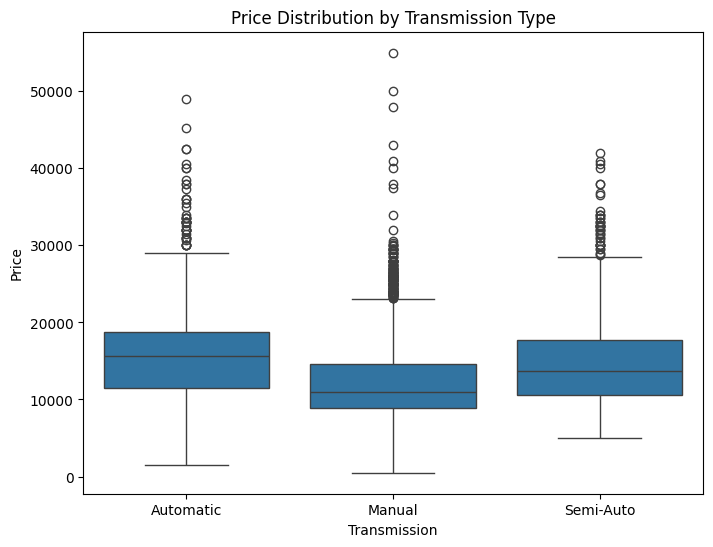

              outliers  Outliers %
transmission                      
Automatic           46    3.379868
Manual             187    1.205052
Semi-Auto           42    3.863845


In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='transmission', y='price')

plt.title('Price Distribution by Transmission Type')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.show()

# Group the dataframe by 'transmission' type, isolate the 'price' column, and apply the outlier function
outlier_counts = df.groupby('transmission')['price'].apply(count_outliers).rename("outliers")
outlier_counts_per = df.groupby('transmission')['price'].apply(lambda g: 100 * (count_outliers(g) /len(g))).rename("Outliers %")
# This is the "apply" step: it takes the custom function count_outliers
#(the one defined just above, using the IQR rule) and runs it separately on each
# group's price Series.
# So internally, pandas does roughly:
# count_outliers(df[df['transmission'] == 'Automatic']['price'])
# count_outliers(df[df['transmission'] == 'Manual']['price'])
# count_outliers(df[df['transmission'] == 'Semi-Auto']['price'])
print(pd.concat([outlier_counts, outlier_counts_per], axis=1))

In [ ]:
df['transmission'].value_counts()

,count
transmission,
Manual,15518
Automatic,1361
Semi-Auto,1087


### 4.-Generate the regression plot between mpg parameter and the price to determine the correlation type between the two.

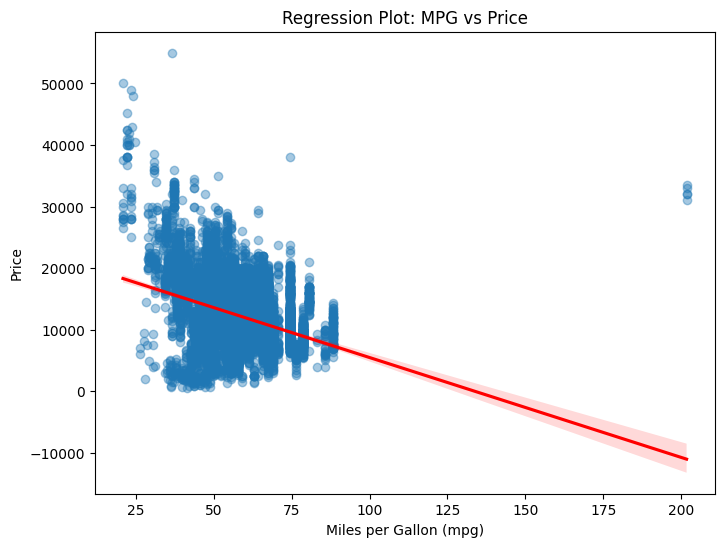

Correlation between mpg and price: -0.346


In [ ]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='mpg', y='price', scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'})

plt.title('Regression Plot: MPG vs Price')
plt.xlabel('Miles per Gallon (mpg)')
plt.ylabel('Price')
plt.show()
corr_val = df['mpg'].corr(df['price'])
print(f"Correlation between mpg and price: {corr_val:.3f}")

# Model Development and Evaluation

### 1.- Fit a linear regression model to predict the price using the feature mpg. Then calculate the R^2 and MSE values for the model.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Define feature (X) and target (y)
X = df[['mpg']]   # double brackets -> keeps it as a DataFrame (2D), required by sklearn
y = df['price']   # target can stay as a Series (1D)
# Why X = df[['mpg']] and not df['mpg']
#
# Scikit-learn's .fit() expects X to be 2D (shape (n_samples, n_features)), even
# for a single feature. df[['mpg']] (double brackets) returns a DataFrame (2D),
# while df['mpg'] (single brackets) returns a Series (1D) and would raise an
# error or need reshaping (.values.reshape(-1, 1)).

# Fit the linear regression model
lr = LinearRegression()
lr.fit(X, y)

# Generate predictions
y_pred = lr.predict(X)

# Calculate R^2 and MSE
r2_mpg = r2_score(y, y_pred)
mse_mpg = mean_squared_error(y, y_pred)

print(f"R^2: {r2_mpg:.4f}")
# R² (coefficient of determination) Represents the proportion of variance in price explained by mpg.
print(f"MSE: {mse_mpg:.2f}")
# The average of the squared differences between actual and predicted prices.
# it's in price² units (e.g., "dollars squared"), which isn't very intuitive on its own
import numpy as np
rmse_mpg = np.sqrt(mse_mpg)
print(f"RMSE: {rmse_mpg:.2f}")
# RMSE tells you, roughly, "on average, predictions are off by about $X" — much
# easier to explain to a non-technical audience (e.g., "the model's predictions
#are typically off by about $3,500").

# Optional: inspect the fitted line's parameters
print(f"Intercept: {lr.intercept_:.2f}")
print(f"Coefficient (slope): {lr.coef_[0]:.2f}")

R^2: 0.1200
MSE: 19781452.81
RMSE: 4447.63
Intercept: 21672.65
Coefficient (slope): -162.21


### 2.-Fit a linear regression model to predict the price using the following set of features. year, mileage, tax, mpg and engineSize. Calculate the R^2 and MSE values for this model.

In [ ]:
# Define features (X) and target (y)
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features]
y = df['price']

# Fit the linear regression model
lr = LinearRegression()
lr.fit(X, y)

# Generate predictions
y_pred = lr.predict(X)

# Calculate R^2 and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

print(f"R^2: {r2:.4f}")
print(f"MSE: {mse:.2f}")
rmse = np.sqrt(mse)
print(f"RMSE: {rmse:.2f}")
# Optional: inspect coefficients to see each feature's contribution
for feature, coef in zip(features, lr.coef_):
    print(f"{feature}: {coef:.2f}")
print(f"Intercept: {lr.intercept_:.2f}")

R^2: 0.7267
MSE: 6142626.29
RMSE: 2478.43
year: 1217.51
mileage: -0.06
tax: 0.78
mpg: -81.16
engineSize: 5350.59
Intercept: -2444534.40


In [ ]:
print(f"Single-feature (mpg only)  -> R²: {r2_mpg:.4f}, MSE: {mse_mpg:.2f}, RMSE: {rmse_mpg:.2f}")
print(f"Multi-feature (5 features) -> R²: {r2:.4f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
#

Single-feature (mpg only)  -> R²: 0.1200, MSE: 19781452.81, RMSE: 4447.63
Multi-feature (5 features) -> R²: 0.7267, MSE: 6142626.29, RMSE: 2478.43


### 3.-For the same set of features as in the question above, create a pipeline model object that uses standard scalar, second degree polynomial features and a linear regression model. Calculate the R^2 value and the MSE value for this model.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


# Define features (X) and target (y)
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features]
y = df['price']

# Build the pipeline: scale -> generate polynomial features -> fit linear regression
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

# Fit the pipeline
pipe.fit(X, y)

# Generate predictions
y_pred = pipe.predict(X)

# Calculate R^2 and MSE
r2_pipe = r2_score(y, y_pred)
mse_pipe = mean_squared_error(y, y_pred)
rmse_pipe = np.sqrt(mse_pipe)

print(f"R^2: {r2_pipe:.4f}")
print(f"MSE: {mse_pipe:.2f}")
print(f"RMSE: {rmse_pipe:.2f}")

R^2: 0.7667
MSE: 5245201.07
RMSE: 2290.24


In [ ]:
print(f"Single-feature (mpg only)       -> R²: {r2_mpg:.4f}, MSE: {mse_mpg:.2f}, RMSE: {rmse_mpg:.2f}")
print(f"Multi-feature (5 features)      -> R²: {r2:.4f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
print(f"Multi-feature (5 features pipe) -> R²: {r2_pipe:.4f}, MSE: {mse_pipe:.2f}, RMSE: {rmse_pipe:.2f}")

Single-feature (mpg only)       -> R²: 0.1200, MSE: 19781452.81, RMSE: 4447.63
Multi-feature (5 features)      -> R²: 0.7267, MSE: 6142626.29, RMSE: 2478.43
Multi-feature (5 features pipe) -> R²: 0.7667, MSE: 5245201.07, RMSE: 2290.24


### 4.-For the same set of features, split the data into training and testing data parts. Assume testing part to be 20%. Create and fit a Ridge regression object using the training data, set the regularization parameter to 0.1, and calculate the R^2 using the test data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Define features (X) and target (y)
features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
X = df[features]
y = df['price']

# Split into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Create and fit the Ridge regression model
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train, y_train)

# Predict on the test data
y_pred = ridge_model.predict(x_test)

# Calculate R^2 on the test data
r2_test = r2_score(y_test, y_pred)
print(f"R^2 (test data): {r2_test:.4f}")

# Optional: MSE on test data too, for comparison with earlier models
mse_test = mean_squared_error(y_test, y_pred)
print(f"MSE (test data): {mse_test:.2f}")
rmse_test = np.sqrt(mse_test)
print(f"RMSE (test data): {rmse_test:.2f}")

R^2 (test data): 0.7445
MSE (test data): 6420395.75
RMSE (test data): 2533.85


In [ ]:
print(f"Single-feature (mpg only)       -> R²: {r2_mpg:.4f}, MSE: {mse_mpg:.2f}, RMSE: {rmse_mpg:.2f}")
print(f"Multi-feature (5 features)      -> R²: {r2:.4f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
print(f"Multi-feature (5 features pipe) -> R²: {r2_pipe:.4f}, MSE: {mse_pipe:.2f}, RMSE: {rmse_pipe:.2f}")
print(f"Ridge regression                -> R²: {r2_test:.4f}, MSE: {mse_test:.2f}, RMSE: {rmse_test:.2f}")

Single-feature (mpg only)       -> R²: 0.1200, MSE: 19781452.81, RMSE: 4447.63
Multi-feature (5 features)      -> R²: 0.7267, MSE: 6142626.29, RMSE: 2478.43
Multi-feature (5 features pipe) -> R²: 0.7667, MSE: 5245201.07, RMSE: 2290.24
Ridge regression                -> R²: 0.7445, MSE: 6420395.75, RMSE: 2533.85


### 5.-Perform a second order polynomial transform on both the training data and testing data created for the question above. Create and fit a Ridge regression object using the modified training data, set the regularisation parameter to 0.1, and calculate the R^2 and MSE utilising the modified test data.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Perform a 2nd order polynomial transform, fitting only on the training data
pr = PolynomialFeatures(degree=2)
x_train_pr = pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)

# Create and fit the Ridge regression model on the transformed training data
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(x_train_pr, y_train)

# Predict on the transformed test data
y_pred = ridge_model.predict(x_test_pr)

# Calculate R^2 and MSE on the test data
r2_poly = r2_score(y_test, y_pred)
mse_poly = mean_squared_error(y_test, y_pred)
rmse_poly = np.sqrt(mse_poly)
print(f"R^2 (test data): {r2_poly:.4f}")
print(f"MSE (test data): {mse_poly:.2f}")
print(f"RMSE (test data): {rmse_poly:.2f}")

R^2 (test data): 0.7763
MSE (test data): 5620497.13
RMSE (test data): 2370.76


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.18654e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [ ]:
print(f"Single-feature (mpg only)       -> R²: {r2_mpg:.4f}, MSE: {mse_mpg:.2f}, RMSE: {rmse_mpg:.2f}")
print(f"Multi-feature (5 features)      -> R²: {r2:.4f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
print(f"Multi-feature (5 features pipe) -> R²: {r2_pipe:.4f}, MSE: {mse_pipe:.2f}, RMSE: {rmse_pipe:.2f}")
print(f"Ridge regression                -> R²: {r2_test:.4f}, MSE: {mse_test:.2f}, RMSE: {rmse_test:.2f}")
print(f"Polynomial transformatio        -> R²: {r2_poly:.4f}, MSE: {mse_poly:.2f}, RMSE: {rmse_poly:.2f}")

Single-feature (mpg only)       -> R²: 0.1200, MSE: 19781452.81, RMSE: 4447.63
Multi-feature (5 features)      -> R²: 0.7267, MSE: 6142626.29, RMSE: 2478.43
Multi-feature (5 features pipe) -> R²: 0.7667, MSE: 5245201.07, RMSE: 2290.24
Ridge regression                -> R²: 0.7445, MSE: 6420395.75, RMSE: 2533.85
Polynomial transformatio        -> R²: 0.7763, MSE: 5620497.13, RMSE: 2370.76


### 6.-In the question above, perform a Grid Search on ridge regression for a set of values of alpha {0.01, 0.1, 1, 10, 100} with 4-fold cross validation to find the optimum value of alpha to be used for the prediction model.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Define the parameter grid to search over
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

# Create the Ridge estimator and the grid search object (4-fold CV)
ridge = Ridge()
grid_search = GridSearchCV(ridge, param_grid, cv=4, scoring='r2')

# Fit grid search on the polynomial-transformed training data
grid_search.fit(x_train_pr, y_train)

# Best alpha found
best_alpha = grid_search.best_params_['alpha']
print(f"Best alpha: {best_alpha}")
print(f"Best cross-validated R^2: {grid_search.best_score_:.4f}")

# Evaluate the best model on the (held-out) test data
best_ridge = grid_search.best_estimator_
y_pred = best_ridge.predict(x_test_pr)

r2_grid = r2_score(y_test, y_pred)
mse_grid = mean_squared_error(y_test, y_pred)
rmse_grid = np.sqrt(mse_grid)
print(f"R^2 (test data, best alpha): {r2_grid:.4f}")
print(f"MSE (test data, best alpha): {mse_grid:.2f}")

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.80086e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.87242e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.92654e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=3.07598e-25): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.80086e-24): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

Best alpha: 100
Best cross-validated R^2: 0.7548
R^2 (test data, best alpha): 0.7761
MSE (test data, best alpha): 5625390.45


In [ ]:
print(f"Single-feature (mpg only)       -> R²: {r2_mpg:.4f}, MSE: {mse_mpg:.2f}, RMSE: {rmse_mpg:.2f}")
print(f"Multi-feature (5 features)      -> R²: {r2:.4f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")
print(f"Multi-feature (5 features pipe) -> R²: {r2_pipe:.4f}, MSE: {mse_pipe:.2f}, RMSE: {rmse_pipe:.2f}")
print(f"Ridge regression                -> R²: {r2_test:.4f}, MSE: {mse_test:.2f}, RMSE: {rmse_test:.2f}")
print(f"Polynomial transformatio        -> R²: {r2_poly:.4f}, MSE: {mse_poly:.2f}, RMSE: {rmse_poly:.2f}")
print(f"Grid search (best alpha)        -> R²: {r2_grid:.4f}, MSE: {mse_grid:.2f}, RMSE: {rmse_grid:.2f}")

Single-feature (mpg only)       -> R²: 0.1200, MSE: 19781452.81, RMSE: 4447.63
Multi-feature (5 features)      -> R²: 0.7267, MSE: 6142626.29, RMSE: 2478.43
Multi-feature (5 features pipe) -> R²: 0.7667, MSE: 5245201.07, RMSE: 2290.24
Ridge regression                -> R²: 0.7761, MSE: 5625390.45, RMSE: 2533.85
Polynomial transformatio        -> R²: 0.7763, MSE: 5620497.13, RMSE: 2370.76
Grid search (best alpha)        -> R²: 0.7761, MSE: 5625390.45, RMSE: 2371.79


## check price skew

In [ ]:
df['price'].describe()

,price
count,17966.000000
mean,12279.534844
std,4741.343657
min,495.000000
25%,8999.000000
50%,11291.000000
75%,15299.000000
max,54995.000000


<Axes: >

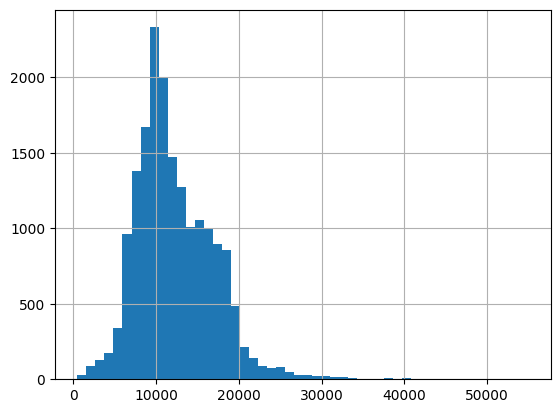

In [ ]:

df['price'].hist(bins=50)

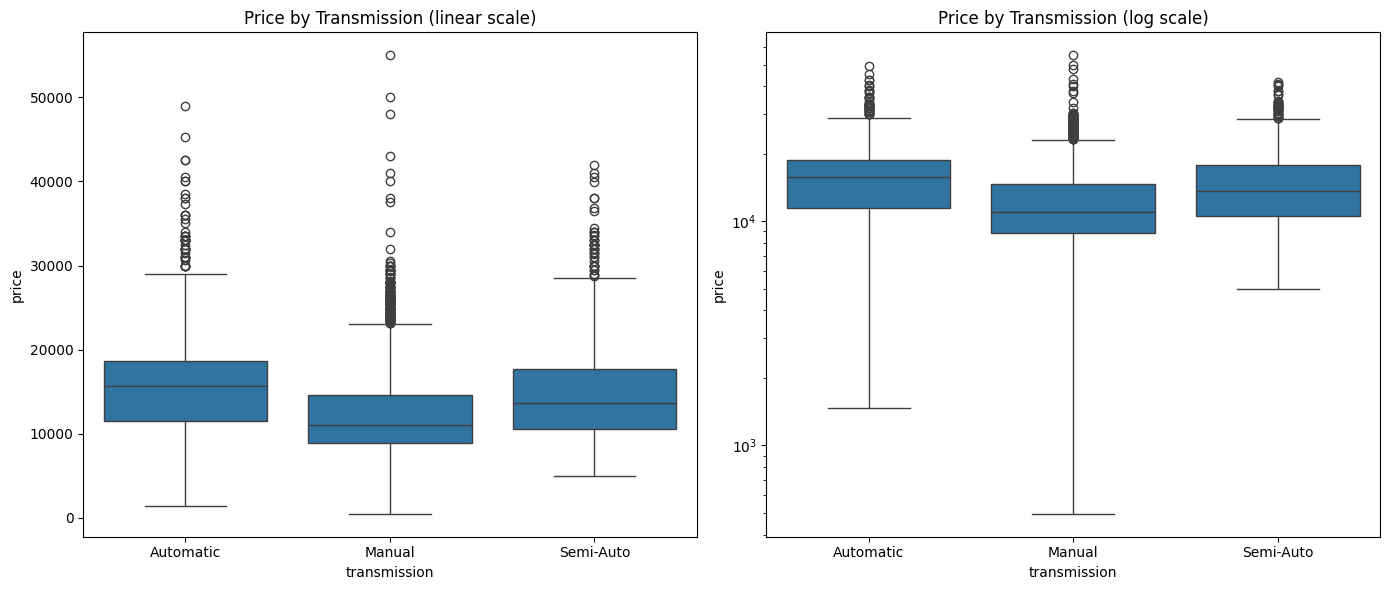

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='transmission', y='price', ax=axes[0])
axes[0].set_title('Price by Transmission (linear scale)')

sns.boxplot(data=df, x='transmission', y='price', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Price by Transmission (log scale)')

plt.tight_layout()
plt.show()
